# Ноутбук 09: Instruction Tuning + LoRA )

**Цель:** дообучить генеративную модель под формат «инструкция -> ответ» с помощью LoRA.

- Датасет: `freQuensy23/ru-alpaca-cleaned`
- Базовая модель: `sberbank-ai/rugpt3small_based_on_gpt2`
- Метод: PEFT LoRA
- Метрика: `eval_loss` и `perplexity`

Что изменено:
1. Полностью русскоязычные инструкции и шаблон промпта.
2. Маскировка токенов промпта: лосс считается только по ответу.
3. Сравнение качества до/после обучения и примеры генерации.


In [2]:
# Если запускаете в новом окружении, раскомментируйте:
# %pip install -q transformers datasets peft accelerate

import os
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    default_data_collator,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from huggingface_hub.utils import disable_progress_bars

disable_progress_bars()
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('torch:', torch.__version__)
print('GPU доступен:', torch.cuda.is_available())


torch: 2.9.1+cu126
GPU доступен: True


## Шаг 1: Датасет инструкций и формат промпта

In [3]:
dataset = load_dataset('freQuensy23/ru-alpaca-cleaned', split='train').shuffle(seed=SEED)

print('Датасет загружен')
print('Размер:', len(dataset))
print('Поля:', dataset.column_names)

for idx in [0, 20, 120]:
    ex = dataset[idx]
    print()
    print(f'--- Пример {idx} ---')
    print('Инструкция:', ex['instruction'])
    if ex['input'].strip():
        print('Вход:', ex['input'][:140])
    print('Ответ:', ex['output'][:140])


Датасет загружен
Размер: 26981
Поля: ['output', 'instruction', 'input']

--- Пример 0 ---
Инструкция: Создайте заголовок для данной статьи.
Вход: История: После многих лет неопределенности было замечено, что находящийся под угрозой исчезновения вид пумы процветает в своей среде обитани
Ответ: "Популяция пумы, находящаяся под угрозой исчезновения, процветает после многих лет неопределенности"

--- Пример 20 ---
Инструкция: Придумайте сравнение для описания цвета глаз человека.
Ответ: Ее глаза были такими же голубыми, как чистое небо в ясный летний день.

--- Пример 120 ---
Инструкция: Спрягайте глагол в простом настоящем времени.
Вход: Ходить
Ответ: Я иду пешком
Ты идешь
Он/она/оно ходит
Мы идем пешком
Они ходят
Ты (во множественном числе) идешь пешком.


In [4]:
PROMPT_WITH_INPUT = """Ниже дана инструкция и дополнительный контекст. Дай полезный и точный ответ.

### Инструкция:
{instruction}

### Вход:
{input}

### Ответ:
{output}"""

PROMPT_WITHOUT_INPUT = """Ниже дана инструкция. Дай полезный и точный ответ.

### Инструкция:
{instruction}

### Ответ:
{output}"""


def format_prompt(example):
    if example['input'].strip():
        text = PROMPT_WITH_INPUT.format(
            instruction=example['instruction'],
            input=example['input'],
            output=example['output'],
        )
    else:
        text = PROMPT_WITHOUT_INPUT.format(
            instruction=example['instruction'],
            output=example['output'],
        )
    return {'text': text}

formatted = dataset.map(format_prompt, remove_columns=dataset.column_names)
print('Пример форматированного текста:')
print(formatted[0]['text'][:700])



Map: 100%|██████████| 26981/26981 [00:02<00:00, 9655.51 examples/s]

Пример форматированного текста:
Ниже дана инструкция и дополнительный контекст. Дай полезный и точный ответ.

### Инструкция:
Создайте заголовок для данной статьи.

### Вход:
История: После многих лет неопределенности было замечено, что находящийся под угрозой исчезновения вид пумы процветает в своей среде обитания.

### Ответ:
"Популяция пумы, находящаяся под угрозой исчезновения, процветает после многих лет неопределенности"


In [5]:
# Берем подвыборку для быстрого обучения
split = formatted.train_test_split(test_size=0.1, seed=SEED)
train_raw = split['train'].select(range(400))
eval_raw = split['test'].select(range(80))

print('Train:', len(train_raw), 'Eval:', len(eval_raw))


Train: 400 Eval: 80


## Шаг 2: Модель и LoRA

In [6]:
MODEL_NAME = 'sberbank-ai/rugpt3small_based_on_gpt2'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

total_params = sum(p.numel() for p in base_model.parameters())
print('Базовая модель:', MODEL_NAME)
print(f'Параметров: {total_params:,} ({total_params/1e6:.1f}M)')
print('PAD token id:', tokenizer.pad_token_id)


Loading weights: 100%|██████████| 149/149 [00:00<00:00, 29110.83it/s]
The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Базовая модель: sberbank-ai/rugpt3small_based_on_gpt2
Параметров: 163,834,368 (163.8M)
PAD token id: 0


In [7]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=['c_attn', 'c_proj'],
    bias='none',
)

model = get_peft_model(base_model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Обучаемых параметров LoRA: {trainable_params:,} ({trainable_params/total_params*100:.2f}% от модели)')


Обучаемых параметров LoRA: 811,008 (0.50% от модели)


c:\anacon\envs\nlp_env\Lib\site-packages\peft\tuners\lora\layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## Шаг 3: Токенизация с маской ответа

In [8]:
MAX_LENGTH = 160
RESPONSE_MARKER = "### Ответ:\n"
response_marker_ids = tokenizer.encode(RESPONSE_MARKER, add_special_tokens=False)


def tokenize_with_response_mask(examples):
    tokenized = tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length',
    )

    labels_batch = []
    for input_ids in tokenized['input_ids']:
        response_start = None
        marker_len = len(response_marker_ids)

        for i in range(len(input_ids) - marker_len + 1):
            if input_ids[i:i + marker_len] == response_marker_ids:
                response_start = i + marker_len
                break

        if response_start is None:
            labels = input_ids.copy()
        else:
            labels = [-100] * response_start + input_ids[response_start:]

        labels = [label if tok_id != tokenizer.pad_token_id else -100 for tok_id, label in zip(input_ids, labels)]
        labels_batch.append(labels)

    tokenized['labels'] = labels_batch
    return tokenized

train_ds = train_raw.map(tokenize_with_response_mask, batched=True, remove_columns=['text'])
eval_ds = eval_raw.map(tokenize_with_response_mask, batched=True, remove_columns=['text'])

print('Токенизация завершена')
print('Train features:', train_ds.column_names)
print('Длина последовательности:', len(train_ds[0]['input_ids']))


Map: 100%|██████████| 80/80 [00:00<00:00, 1045.31 examples/s]

Токенизация завершена
Train features: ['input_ids', 'attention_mask', 'labels']
Длина последовательности: 160


In [9]:
example = train_ds[0]
n_total = len(example['labels'])
n_masked = sum(1 for x in example['labels'] if x == -100)
print('Проверка маскировки:')
print('Всего токенов:', n_total)
print('Замаскировано (-100):', n_masked)
print('Токенов ответа:', n_total - n_masked)


Проверка маскировки:
Всего токенов: 160
Замаскировано (-100): 146
Токенов ответа: 14


## Шаг 4: Обучение

In [10]:
training_args = TrainingArguments(
    output_dir='./results_instruction_ru',
    num_train_epochs=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=3e-4,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='no',
    logging_strategy='steps',
    logging_steps=20,
    report_to='none',
    disable_tqdm=True,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=default_data_collator,
)

print('Trainer готов')
print('Эпох:', training_args.num_train_epochs)
print('Effective batch size:', training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)


Trainer готов
Эпох: 1
Effective batch size: 16


In [11]:
baseline_eval = trainer.evaluate()
baseline_ppl = math.exp(baseline_eval['eval_loss'])

print('До обучения:')
print(f"  eval_loss: {baseline_eval['eval_loss']:.4f}")
print(f"  perplexity: {baseline_ppl:.2f}")


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


{'eval_loss': '3.22', 'eval_model_preparation_time': '0.007', 'eval_runtime': '2.543', 'eval_samples_per_second': '31.45', 'eval_steps_per_second': '15.73', 'epoch': 0}
До обучения:
  eval_loss: 3.2195
  perplexity: 25.02


In [12]:
train_result = trainer.train()

print('Обучение завершено')
print(f"Время: {train_result.metrics['train_runtime']:.1f} сек")
print(f"Train loss: {train_result.metrics['train_loss']:.3f}")


{'loss': '3.468', 'grad_norm': '0.3673', 'learning_rate': '7.2e-05', 'epoch': '0.8'}
{'eval_loss': '2.645', 'eval_model_preparation_time': '0.007', 'eval_runtime': '2.347', 'eval_samples_per_second': '34.08', 'eval_steps_per_second': '17.04', 'epoch': '1'}
{'train_runtime': '29.46', 'train_samples_per_second': '13.58', 'train_steps_per_second': '0.849', 'train_loss': '3.387', 'epoch': '1'}
Обучение завершено
Время: 29.5 сек
Train loss: 3.387


{'eval_loss': '2.645', 'eval_model_preparation_time': '0.007', 'eval_runtime': '2.36', 'eval_samples_per_second': '33.9', 'eval_steps_per_second': '16.95', 'epoch': '1'}
После обучения:
  eval_loss: 2.6446
  perplexity: 14.08

Perplexity: 25.02 -> 14.08


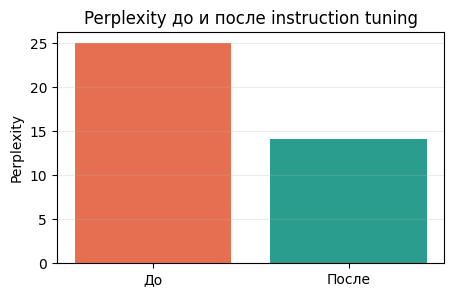

In [13]:
final_eval = trainer.evaluate()
final_ppl = math.exp(final_eval['eval_loss'])

print('После обучения:')
print(f"  eval_loss: {final_eval['eval_loss']:.4f}")
print(f"  perplexity: {final_ppl:.2f}")
print()
print(f"Perplexity: {baseline_ppl:.2f} -> {final_ppl:.2f}")

plt.figure(figsize=(5, 3))
plt.bar(['До', 'После'], [baseline_ppl, final_ppl], color=['#e76f51', '#2a9d8f'])
plt.title('Perplexity до и после instruction tuning')
plt.ylabel('Perplexity')
plt.grid(axis='y', alpha=0.25)
plt.show()


## Шаг 5: Сравнение ответов до и после

In [14]:
def build_inference_prompt(instruction, input_text=''):
    if input_text.strip():
        return PROMPT_WITH_INPUT.format(instruction=instruction, input=input_text, output='')
    return PROMPT_WITHOUT_INPUT.format(instruction=instruction, output='')


def generate_response(model_obj, instruction, input_text='', max_new_tokens=90):
    prompt = build_inference_prompt(instruction, input_text)
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=MAX_LENGTH).to(model_obj.device)
    prompt_len = inputs['input_ids'].shape[1]

    model_obj.eval()
    with torch.no_grad():
        output_ids = model_obj.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.92,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    new_tokens = output_ids[0][prompt_len:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


test_items = [
    {'instruction': 'Перечисли три способа снизить стресс в течение рабочего дня.', 'input': ''},
    {'instruction': 'Объясни простыми словами, что такое машинное обучение.', 'input': ''},
    {'instruction': 'Определи тональность текста', 'input': 'Мне очень понравился этот сервис, он сэкономил мне много времени.'},
]

rows = []
for item in test_items:
    before = generate_response(base_model, item['instruction'], item['input'])
    after = generate_response(model, item['instruction'], item['input'])

    rows.append(
        {
            'instruction': item['instruction'],
            'input': item['input'],
            'before': before,
            'after': after,
        }
    )

compare_df = pd.DataFrame(rows)
display(compare_df[['instruction', 'before', 'after']])


,instruction,before,after
0,Перечисли три способа снизить стресс в течение...,"Если вы едите в первый день, то съедайте 3–4 п...",1. Встать в 9.00. Принять душ и лечь в постель...
1,"Объясни простыми словами, что такое машинное о...",С помощью этой инструкции можно научиться игра...,Пункт 1. Вы должны учить детей в первую очеред...
2,Определи тональность текста,"Я знаю, что многие пишут про ""Правила чтения"",...","Это сервис, который помогает людям создавать и..."


## Шаг 6: Сохранение LoRA адаптера и merged-модели

In [15]:
adapter_dir = './my_ru_instruction_lora_adapter'
model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)

print('Адаптер сохранен в', adapter_dir)


Адаптер сохранен в ./my_ru_instruction_lora_adapter


In [16]:
base_for_load = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
loaded_lora = PeftModel.from_pretrained(base_for_load, adapter_dir)
merged_model = loaded_lora.merge_and_unload()

merged_dir = './my_ru_instruction_merged'
merged_model.save_pretrained(merged_dir)
tokenizer.save_pretrained(merged_dir)

print('Merged-модель сохранена в', merged_dir)


Loading weights: 100%|██████████| 149/149 [00:00<00:00, 21249.62it/s]
The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.98s/it]

Merged-модель сохранена в ./my_ru_instruction_merged


In [17]:
current_rank = lora_config.r
current_trainable = trainable_params

rank_df = pd.DataFrame(
    [
        {'rank_r': r, 'estimated_trainable_params': int(current_trainable * r / current_rank)}
        for r in [4, 8, 16, 32]
    ]
)
rank_df['share_of_base_%'] = rank_df['estimated_trainable_params'] / total_params * 100

display(rank_df)
print('Оценка показывает, как растет число адаптируемых параметров при увеличении ранга LoRA.')


,rank_r,estimated_trainable_params,share_of_base_%
0,4,405504,0.247509
1,8,811008,0.495017
2,16,1622016,0.990034
3,32,3244032,1.980068


Оценка показывает, как растет число адаптируемых параметров при увеличении ранга LoRA.


## Итоги

1. Проведен instruction tuning русскоязычной GPT-модели через LoRA.
2. Реализована маскировка промпта, чтобы обучение шло по токенам ответа.
3. На валидации после обучения снизились `eval_loss` и `perplexity`.
4. Адаптер и merged-модель сохранены для дальнейшего применения.
